# Pacotes

In [5]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
from torchsummary import summary

# Carregando Arquivos no Colab

In [2]:
# Carregar o "historico_vendas" e o "pesos_modelo.pth"
from google.colab import files
dados = files.upload()

Saving historico_vendas.xlsx to historico_vendas.xlsx


In [6]:
df = pd.read_excel("historico_vendas.xlsx")

print("Primeiras 5 linhas:")
display(df.head())

print("\n5 linhas aleatórias (amostra):")
display(df.sample(5))

print("\nÚltimas 5 linhas:")
display(df.tail())

Primeiras 5 linhas:


,ID,Produto,Descrição,Data,Quantidade Vendida
0,1,Anel,Quadrado Abaulado,2023-01-01,0
1,2,Brincos,Franja,2023-01-01,0
2,3,Bracelete,Elos Cravejados,2023-01-01,0
3,4,Bracelete,Personalizado,2023-01-01,0
4,5,Anel,Com Pedra,2023-01-01,0



5 linhas aleatórias (amostra):


,ID,Produto,Descrição,Data,Quantidade Vendida
48,5,Anel,Com Pedra,2023-01-05,42
6748,6,Brincos,Vírgula,2024-09-05,9
11656,8,Pulseira,Esteira,2025-11-25,21
6204,1,Anel,Quadrado Abaulado,2024-07-18,11
10903,3,Bracelete,Elos Cravejados,2025-09-18,10



Últimas 5 linhas:


,ID,Produto,Descrição,Data,Quantidade Vendida
12051,7,Colar,Choker Esteira,2025-12-31,33
12052,8,Pulseira,Esteira,2025-12-31,13
12053,9,Colar,Choker Malha,2025-12-31,40
12054,10,Anel,Trevo,2025-12-31,19
12055,11,Brincos,Pérola,2025-12-31,45


# Processamento de Dados I

In [7]:
# Garantindo que o a Coluna Data esteja no formato correto
df["Data"] = pd.to_datetime(df["Data"])

In [8]:
# Extraindo características da coluna Data
df["dia_semana"] = df["Data"].dt.dayofweek
df["dia_mes"] = df["Data"].dt.day
df["mes"] = df["Data"].dt.month

# Criando uma cópia temporária para renomear as novas colunas para exibição.
print("Primeiras 5 linhas:")
df_display = df.rename(columns={'dia_semana': 'Dia da Semana', 'dia_mes': 'Dia do Mês', 'mes':'Mês do Ano'})[['ID', 'Produto', 'Data', 'Quantidade Vendida', 'Dia da Semana', 'Dia do Mês', 'Mês do Ano']]
display(df_display.head())

Primeiras 5 linhas:


,ID,Produto,Data,Quantidade Vendida,Dia da Semana,Dia do Mês,Mês do Ano
0,1,Anel,2023-01-01,0,6,1,1
1,2,Brincos,2023-01-01,0,6,1,1
2,3,Bracelete,2023-01-01,0,6,1,1
3,4,Bracelete,2023-01-01,0,6,1,1
4,5,Anel,2023-01-01,0,6,1,1


In [9]:
# Ajustando nossa Quantidade Vendida (nossa variável "Y") para ter 7 colunas, cada coluna representará t+n, começando em 1 até 7 (dias no futuro)
# A ideia é criar 7 neurônios de saída, cada um aprendendo uma data futura. A demanda final, estimada para uma semana, será a soma das 7 saídas
# Dessa maneira também é possível estimar demandas para intervalos menores de tempo

# Passo 1: Ordenação Cronológica e por Produto do DF
df_sorted = df.sort_values(by=['ID', 'Data']).reset_index(drop=True)

# Passo 2: Criação dos Alvos Futuros (Horizontes de Previsão)
# O laço "for" rodará 7 vezes. Em cada rodada ele agrupa os dados por produto e usa a função ".shift(-i)" na coluna de vendas
# O shift(-1) pega a venda de amanhã e coloca na linha de hoje. O shift(-2) pega a venda de depois de amanhã, e assim por diante, criando as colunas t+1 até t+7.
target_cols = []
for i in range(1, 8):
    shifted_target = df_sorted.groupby('ID')['Quantidade Vendida'].shift(-i)
    df_sorted[f't+{i}'] = shifted_target
    target_cols.append(f't+{i}')

# O novo "Y" será um DataFrame com as 7 colunas de criadas
Y_multioutput = df_sorted[target_cols]

In [10]:
# Criação das variáveis de entrada "X"
# As variáveis de entrada "X" também precisarão ser construídas a partir de "df_sorted" para garantir o alinhamento de índices
# Ao mesmo tempo, estamos realizando as transformações necessárias das entradas para serem utilizados pelo modelo

# Aplicação de transformações One-Hot Encoding dos IDs
X_produtos_sorted = pd.get_dummies(df_sorted["ID"], dtype=int, prefix="id")

# Aplicação de transformações seno/cosseno para características temporais
# Dia da semana
df_sorted['sin_dia_semana'] = np.sin(2 * np.pi * df_sorted['dia_semana'] / 7)
df_sorted['cos_dia_semana'] = np.cos(2 * np.pi * df_sorted['dia_semana'] / 7)

# Dia do mês
df_sorted['sin_dia_mes'] = np.sin(2 * np.pi * df_sorted['dia_mes'] / df_sorted['Data'].dt.daysinmonth)
df_sorted['cos_dia_mes'] = np.cos(2 * np.pi * df_sorted['dia_mes'] / df_sorted['Data'].dt.daysinmonth)

# Mês do ano
df_sorted['sin_mes'] = np.sin(2 * np.pi * df_sorted['mes'] / 12)
df_sorted['cos_mes'] = np.cos(2 * np.pi * df_sorted['mes'] / 12)

# Juntando todas as variáveis "X" geradas lado a lado
X_sorted = pd.concat([
    X_produtos_sorted,
    df_sorted[['sin_dia_semana', 'cos_dia_semana']],
    df_sorted[['sin_dia_mes', 'cos_dia_mes']],
    df_sorted[['sin_mes', 'cos_mes']]
], axis=1)

In [11]:
# Combinar as variáveis de entrada "X" e as colunas "Y" em um único DF para facilitar a remoção de NaNs e manter o alinhamento com a coluna "Data" para o split temporal.
df_model = pd.concat([df_sorted[['ID', 'Data']], X_sorted, Y_multioutput], axis=1)

# O ".dropna()" elimina as linhas finais do DF que ficaram incompletas (as últimas 7 linhas de cada produto não possuem "futuro" para buscar no banco de dados)
df_model.dropna(inplace=True)

# Separação final de "X" e "Y"
X_final = df_model.iloc[:, 2: (2 + X_sorted.shape[1])].copy() # Ignorar ID e Data para "X"
Y_final = df_model[target_cols].copy()

print("Dimensões finais de X para o modelo:", X_final.shape)
display(X_final.head())

print("\nDimensões finais de Y para o modelo:", Y_final.shape)
display(Y_final.head())

Dimensões finais de X para o modelo: (11979, 17)


,id_1,id_2,id_3,id_4,id_5,id_6,id_7,id_8,id_9,id_10,id_11,sin_dia_semana,cos_dia_semana,sin_dia_mes,cos_dia_mes,sin_mes,cos_mes
0,1,0,0,0,0,0,0,0,0,0,0,-0.781831,0.623490,0.201299,0.979530,0.5,0.866025
1,1,0,0,0,0,0,0,0,0,0,0,0.000000,1.000000,0.394356,0.918958,0.5,0.866025
2,1,0,0,0,0,0,0,0,0,0,0,0.781831,0.623490,0.571268,0.820763,0.5,0.866025
3,1,0,0,0,0,0,0,0,0,0,0,0.974928,-0.222521,0.724793,0.688967,0.5,0.866025
4,1,0,0,0,0,0,0,0,0,0,0,0.433884,-0.900969,0.848644,0.528964,0.5,0.866025



Dimensões finais de Y para o modelo: (11979, 7)


,t+1,t+2,t+3,t+4,t+5,t+6,t+7
0,10.0,11.0,10.0,11.0,10.0,12.0,0.0
1,11.0,10.0,11.0,10.0,12.0,0.0,9.0
2,10.0,11.0,10.0,12.0,0.0,9.0,9.0
3,11.0,10.0,12.0,0.0,9.0,9.0,11.0
4,10.0,12.0,0.0,9.0,9.0,11.0,9.0


# Separação Treino/Validação/Teste

In [12]:
# Utilizaremos Validação Temporal Simples com Ponto Fixo, separação por ano
# Importante excluir os últimos 7 dias de cada ano, pois estarão olhando dados futuros (data leakage)

# Treinamento -> ano de 2023
X_train = X_final[(df_model["Data"] >= "2023-01-01") & (df_model["Data"] <= "2023-12-24")]
Y_train = Y_final[(df_model["Data"] >= "2023-01-01") & (df_model["Data"] <= "2023-12-24")]
print("X_train:", X_train.shape)
print("Y_train:", Y_train.shape)

# Validação -> ano de 2024
X_val = X_final[(df_model["Data"] >= "2024-01-01") & (df_model["Data"] <= "2024-12-24")]
Y_val = Y_final[(df_model["Data"] >= "2024-01-01") & (df_model["Data"] <= "2024-12-24")]
print("\nX_val:", X_val.shape)
print("Y_val:", Y_val.shape)

# Teste -> ano de 2025
X_test = X_final[(df_model["Data"] >= "2025-01-01") & (df_model["Data"] <= "2025-12-24")]
Y_test = Y_final[(df_model["Data"] >= "2025-01-01") & (df_model["Data"] <= "2025-12-24")]
print("\nX_test:", X_test.shape)
print("Y_test:", Y_test.shape)

X_train: (3938, 17)
Y_train: (3938, 7)

X_val: (3949, 17)
Y_val: (3949, 7)

X_test: (3938, 17)
Y_test: (3938, 7)


# Processamento de Dados II

In [13]:
# Aplicando a Normalização no Atributo "Quantidade Vendida"
# Apesar de contar como pré-processamento, deve ser feita apenas após a seperação dos conjuntos para evitar vazamento de dados (data leakage)

scaler_y = MinMaxScaler()
Y_train_scaled = scaler_y.fit_transform(Y_train)
Y_val_scaled = scaler_y.transform(Y_val)
Y_test_scaled = scaler_y.transform(Y_test)

print("Dimensões de y_train (escalado):", Y_train.shape)
print("Primeiras 5 linhas de y_train (escalado):\n", Y_train_scaled[:1])

Dimensões de y_train (escalado): (3938, 7)
Primeiras 5 linhas de y_train (escalado):
 [[0.13157895 0.14473684 0.13157895 0.14473684 0.13157895 0.15789474
  0.        ]]


# Transformação dos Dados em Tensores Pytorch

In [14]:
x_train = torch.FloatTensor(X_train.values)
y_train = torch.FloatTensor(Y_train_scaled)

x_val = torch.FloatTensor(X_val.values)
y_val = torch.FloatTensor(Y_val_scaled)

x_test = torch.FloatTensor(X_test.values)
y_test = torch.FloatTensor(Y_test_scaled)

# Definição do Modelo MLP

In [40]:
class MLP(nn.Module):
    def __init__(self, input_dim, output_dim, dropout_prob):
        super(MLP, self).__init__()
        self.rede = nn.Sequential(
            nn.Linear(input_dim, 256),  # Primeira camada oculta
            nn.ReLU(),
            nn.Dropout(dropout_prob), # Dropout após a primeira ReLU
            nn.Linear(256, 128), # Segunda camada oculta
            nn.ReLU(),
            nn.Dropout(dropout_prob), # Dropout após a segunda ReLU
            nn.Linear(128, 64), # Terceira camada oculta
            nn.ReLU(),
            nn.Linear(64, 32), # Quarta camada oculta
            nn.ReLU(),
            nn.Linear(32, 16), # Quinta camada oculta
            nn.ReLU(),
            nn.Linear(16, output_dim), # Camada de saída para 7 dias
            nn.ReLU()
        )

    def forward(self, x):
        out = self.rede(x)
        return out

# Instanciação do Modelo

In [47]:
# Parâmetros do Modelo
input_dim = X_train.shape[1]  # 17 entradas: Produto, Dia da Semana, Mês do Ano
output_dim = 7                # 7 saídas: Previsão de demanda (t+1 até t+7)
dropout_prob = 0.20           # Probabilidade de dropout

model = MLP(input_dim, output_dim, dropout_prob) # Criação do modelo

print(model)
summary(model, (input_dim,))

MLP(
  (rede): Sequential(
    (0): Linear(in_features=17, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=128, out_features=64, bias=True)
    (7): ReLU()
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): ReLU()
    (10): Linear(in_features=32, out_features=16, bias=True)
    (11): ReLU()
    (12): Linear(in_features=16, out_features=7, bias=True)
    (13): ReLU()
  )
)
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                  [-1, 256]           4,608
              ReLU-2                  [-1, 256]               0
           Dropout-3                  [-1, 256]               0
            Linear-4                  [-1, 128]          32,896
              ReLU-5                  [-1

# Carregando o Modelo

In [28]:
# Importante, instanciar o modelo com a mesma arquitetura antes de carregar os pesos salvos
arquivo_carregado = 'pesos_modelo.pth'
model.load_state_dict(torch.load(arquivo_carregado, map_location=torch.device('cpu'))) # O "map_location" garante que o modelo seja carregado na CPU, caso tenha sido salvo de uma GPU

# Colocar o modelo em modo de avaliação (importante para inferência)
model.eval()

print(f"Modelo carregado com sucesso!")

Modelo carregado com sucesso!


# Otimizador e Função de Custo

In [48]:
eta = 0.001 # Taxa de aprendizado
loss_function = nn.MSELoss() # Função de custo - Erro quadrático médio
optimizer = torch.optim.Adam(model.parameters(), lr=eta, weight_decay=0.0001) # Otimizador Adam com regularização L2

In [49]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Laço de Treinamento da Rede

In [50]:
def train_network(model,optimizer,loss_function,x_train,y_train,x_val,y_val,num_epochs,train_losses,val_losses, device):
  # Mover o modelo para o dispositivo
  model.to(device)

  # Mover os tensores para o dispositivo
  x_train = x_train.to(device)
  y_train = y_train.to(device)
  x_val = x_val.to(device)
  y_val = y_val.to(device)

  for epoch in range(num_epochs):
    # Zerando os gradientes da época anterior
    optimizer.zero_grad()

    # Fase de propagação
    output_train = model(x_train)

    # Cálculo do erro (função de custo - loss function)
    loss_train = loss_function(output_train, y_train)

    # Fase de retroprogação
    loss_train.backward()

    # atualização dos pesos da rede
    optimizer.step()

    # Avaliando o modelo com o conjunto de validação
    output_val = model(x_val)
    loss_val = loss_function(output_val,y_val)

    train_losses[epoch] = loss_train.item()
    val_losses[epoch] = loss_val.item()

    if (epoch + 1) % 100 == 0: # Frequência de impressão para 100 épocas
      print(f"Epoch {epoch+1}/{num_epochs}, Erro Treino: {loss_train.item():.4f}, Erro Validação: {loss_val.item():.3f}")

import numpy as np

num_epochs = 2000 # Número de épocas
train_losses = np.zeros(num_epochs)
val_losses = np.zeros(num_epochs)

train_network(model,optimizer,loss_function,x_train,y_train,x_val,y_val,num_epochs,train_losses,val_losses, device)


Epoch 100/2000, Erro Treino: 0.0166, Erro Validação: 0.018
Epoch 200/2000, Erro Treino: 0.0052, Erro Validação: 0.006
Epoch 300/2000, Erro Treino: 0.0019, Erro Validação: 0.002
Epoch 400/2000, Erro Treino: 0.0016, Erro Validação: 0.002
Epoch 500/2000, Erro Treino: 0.0016, Erro Validação: 0.002
Epoch 600/2000, Erro Treino: 0.0015, Erro Validação: 0.002
Epoch 700/2000, Erro Treino: 0.0014, Erro Validação: 0.002
Epoch 800/2000, Erro Treino: 0.0014, Erro Validação: 0.002
Epoch 900/2000, Erro Treino: 0.0014, Erro Validação: 0.002
Epoch 1000/2000, Erro Treino: 0.0014, Erro Validação: 0.002
Epoch 1100/2000, Erro Treino: 0.0014, Erro Validação: 0.002
Epoch 1200/2000, Erro Treino: 0.0013, Erro Validação: 0.002
Epoch 1300/2000, Erro Treino: 0.0013, Erro Validação: 0.002
Epoch 1400/2000, Erro Treino: 0.0013, Erro Validação: 0.002
Epoch 1500/2000, Erro Treino: 0.0013, Erro Validação: 0.002
Epoch 1600/2000, Erro Treino: 0.0013, Erro Validação: 0.002
Epoch 1700/2000, Erro Treino: 0.0013, Erro Valida

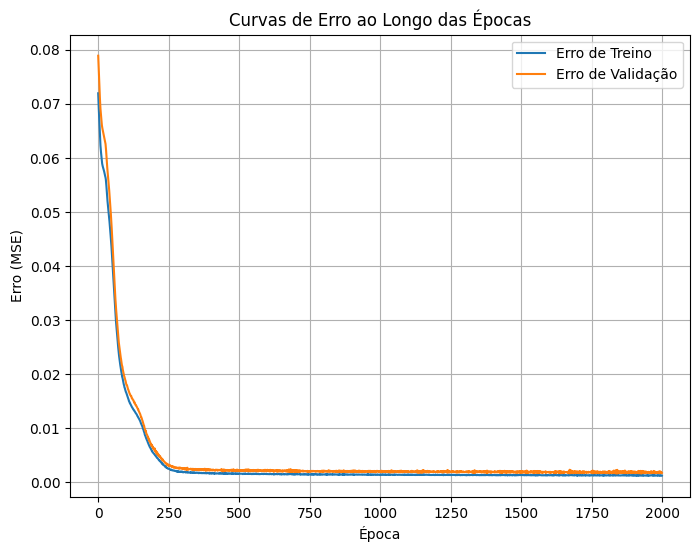

In [51]:
plt.figure(figsize=(8, 6))
plt.plot(train_losses, label='Erro de Treino')
plt.plot(val_losses, label='Erro de Validação')
plt.title('Curvas de Erro ao Longo das Épocas')
plt.xlabel('Época')
plt.ylabel('Erro (MSE)')
plt.legend()
plt.grid(True)
plt.show()

# Resultados

In [52]:
# Mover o modelo para CPU para realizar previsões, se ele estiver na GPU
model.to('cpu')

# Desativar cálculo de gradientes durante a avaliação
with torch.no_grad():

    # Fazer previsões no conjunto de teste
    model.eval() # Colocar o modelo em modo de avaliação
    previsao_tensor = model(x_test) # Realiza a etapa de forward pass do modelo. O resultado é um tensor do PyTorch que contém as previsões do modelo para cada amostra no seu conjunto de teste.

    # Converter as previsões para numpy array
    previsao_np = previsao_tensor.numpy()

    # Reverter as previsões e os valores reais para a escala original (reverter a normalização)
    previsoes = scaler_y.inverse_transform(previsao_np)
    valores_reais = scaler_y.inverse_transform(Y_test_scaled)

    # Calcular o MSE (Mean Squared Error) nos valores na escala original
    mse = np.mean((previsoes - valores_reais)**2)

    print(f"MSE (Conjunto de teste - Valores na escala original): {mse:.4f}")
    print(f"RMSE (Conjunto de teste - Valores na escala original): {np.sqrt(mse):.4f}")

    # Exibir algumas previsões e valores reais para comparação na escala original
    print("\nComparação entre os Valores Reais do histórico vs Valores Previstos:")
    for i in range(10):
        print(f"Real: {valores_reais[i].round(0)}, Previsão: {previsoes[i].round(0)}")

    # Calcular RMSE por Produto
    # Identificar as linhas de df_model que pertencem ao conjunto de teste
    test_set_mask = (df_model["Data"] >= "2025-01-01") & (df_model["Data"] <= "2025-12-24")
    df_model_test_set = df_model[test_set_mask].copy()

    # Obter os IDs de produto para cada entrada no conjunto de teste
    produtos_ids_test = df_model_test_set['ID'].reset_index(drop=True)
    unique_produtos_ids = produtos_ids_test.unique()
    rmse_por_produto_model = {}

    print("\nRMSE por Produto (Modelo MLP / Escala Original)")
    for prod_id in unique_produtos_ids:
        # Obter os índices nos arrays do conjunto de teste (previsoes, valores_reais) que correspondem ao ID do produto atual
        indices_por_produto = produtos_ids_test[produtos_ids_test == prod_id].index

        # Filtrar as previsões e os valores reais para este produto
        prod_previsoes = previsoes[indices_por_produto]
        prod_valores_reais = valores_reais[indices_por_produto]

        # Calcular MSE e RMSE para este produto
        mse_prod = np.mean((prod_previsoes - prod_valores_reais)**2)
        rmse_prod = np.sqrt(mse_prod)
        rmse_por_produto_model[prod_id] = rmse_prod
        print(f"Produto ID {prod_id}: RMSE = {rmse_prod:.3f}")

    # Calcular RMSE por Produto - Previsão pela Média Histórica de Vendas
    train_set_mask = (df_model["Data"] >= "2023-01-01") & (df_model["Data"] <= "2023-12-24")
    df_model_train_set = df_model[train_set_mask].copy()

    # Calcular a média de vendas por produto no conjunto de treino
    media_venda_por_produto_train = df_model_train_set.groupby('ID')['t+1'].mean() # "t+1" pode ser usado como proxy para a media de vendas

    rmse_por_produto_media_baseline = {}
    print("\nRMSE por Produto (Média Histórica de Vendas)")
    for prod_id in unique_produtos_ids:
        # Obter os índices no conjunto de teste para o produto atual
        indices_por_produto = produtos_ids_test[produtos_ids_test == prod_id].index

        # Valores reais para este produto no teste
        prod_valores_reais = valores_reais[indices_por_produto]

        # A "previsão" baseline é simplesmente a média histórica, repetida para os 7 dias
        media_pred = media_venda_por_produto_train.get(prod_id, 0.0) # Se um "prod_id" não for encontrado, retorna 0.0 como padrão
        prod_baseline_predictions = np.full_like(prod_valores_reais, media_pred) # Cria array do mesmo formato preenchido com a média

        # Calcular MSE e RMSE para a baseline
        mse_baseline_prod = np.mean((prod_baseline_predictions - prod_valores_reais)**2)
        rmse_baseline_prod = np.sqrt(mse_baseline_prod)
        rmse_por_produto_media_baseline[prod_id] = rmse_baseline_prod
        print(f"Produto ID {prod_id}: RMSE = {rmse_baseline_prod:.3f}")

    # Consolidar os resultados em um DataFrame para comparação
    comparacao_df = pd.DataFrame({
        'RMSE Modelo MLP': pd.Series(rmse_por_produto_model),
        'RMSE Média Histórica': pd.Series(rmse_por_produto_media_baseline)})

    comparacao_df['Melhora (%)'] = ((comparacao_df['RMSE Média Histórica'] - comparacao_df['RMSE Modelo MLP']) / comparacao_df['RMSE Média Histórica']) * 100
    comparacao_df = comparacao_df.sort_index()

    print("\nComparação de RMSE por Produto")
    display(comparacao_df)



MSE (Conjunto de teste - Valores na escala original): 12.3452
RMSE (Conjunto de teste - Valores na escala original): 3.5136

Comparação entre os Valores Reais do histórico vs Valores Previstos:
Real: [10. 12. 12.  0. 11. 12. 11.], Previsão: [10. 11. 11.  0. 10. 10. 10.]
Real: [12. 12.  0. 11. 12. 11. 11.], Previsão: [10. 11.  0. 10. 10. 10. 10.]
Real: [12.  0. 11. 12. 11. 11. 12.], Previsão: [11.  0. 10. 10. 10. 10. 11.]
Real: [ 0. 11. 12. 11. 11. 12. 12.], Previsão: [ 0. 10. 10. 10. 10. 11. 11.]
Real: [11. 12. 11. 11. 12. 12.  0.], Previsão: [10. 10. 10. 10. 10. 11.  0.]
Real: [12. 11. 11. 12. 12.  0. 11.], Previsão: [10. 10. 10. 11. 11.  0. 10.]
Real: [11. 11. 12. 12.  0. 11. 10.], Previsão: [10. 10. 10. 13.  0. 10. 10.]
Real: [11. 12. 12.  0. 11. 10. 11.], Previsão: [10. 11. 11.  0. 10. 10. 10.]
Real: [12. 12.  0. 11. 10. 11. 10.], Previsão: [10. 12.  0. 10. 10. 10. 10.]
Real: [12.  0. 11. 10. 11. 10. 12.], Previsão: [11.  0. 10. 10. 10. 10. 11.]

RMSE por Produto (Modelo MLP / Esca

,RMSE Modelo MLP,RMSE Média Histórica,Melhora (%)
1,1.346027,4.389189,69.333120
2,2.197918,6.801843,67.686432
3,1.277669,4.022089,68.233708
4,0.968702,3.140400,69.153546
5,6.337020,19.780095,67.962639
6,1.132563,3.579922,68.363484
7,4.528389,14.185247,68.076772
8,1.869656,5.789771,67.707594
9,5.077935,16.419685,69.074099
10,2.520395,7.992130,68.464034


## Exportando o Modelo Treinado

In [53]:
save = 'pesos_modelo.pth'
torch.save(model.state_dict(), save)
files.download(save)

print(f"Pesos do modelo salvos em: {save}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Pesos do modelo salvos em: pesos_modelo.pth
